In [1]:
import numpy as np
import pandas as pd
import os
import cv2
import time
import random
import matplotlib.pyplot as plt
import random

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [2]:
import glob

# Try multiple possible dataset locations
dataset_paths = [
    '../input/Car_Number_Plate',
    './input/Car_Number_Plate',
    '../../input/Car_Number_Plate',
]

paths = []
for dataset_dir in dataset_paths:
    if os.path.exists(dataset_dir):
        for dirname, _, filenames in os.walk(dataset_dir):
            for filename in filenames:
                paths += [os.path.join(dirname, filename)]
        print(f"Found dataset at: {dataset_dir}")
        break

if not paths:
    print("Dataset not found. Please:")
    print("1. Download dataset: kaggle datasets download -d 'car-number-plate-detection'")
    print("2. Extract to: ./input/car-number-plate-detection/")
    print(f"Searched paths: {dataset_paths}")

Found dataset at: ./input/Car_Number_Plate


In [3]:
n=len(paths)
N = random.randint(0, n - 1)

In [4]:
# Try to load labels from file, fallback to default
try:
    with open('../input/yolo-weights-for-licence-plate-detector/classes.names') as f:
        labels = f.read()
except FileNotFoundError:
    # Fallback for local environment
    labels = "license_plate"
    print(f"Warning: classes.names not found. Using default: {labels}")

print(labels)

license_plate


In [5]:
# Define YOLO weights and configuration paths
# Updated to use local extracted files from ./input/
weights_path = './input/yolo-weights-for-licence-plate-detector/lapi.weights'
configuration_path = './input/yolo-weights-for-licence-plate-detector/darknet-yolov3.cfg'

# Check if files exist locally
if not os.path.exists(weights_path):
    print(f"Error: YOLO weights not found at {weights_path}")
    print(f"Please ensure the dataset is extracted to: ./input/yolo-weights-for-licence-plate-detector/")
else:
    print(f"✓ Found weights at {weights_path}")

if not os.path.exists(configuration_path):
    print(f"Error: YOLO config not found at {configuration_path}")
else:
    print(f"✓ Found config at {configuration_path}")

probability_minimum = 0.4
threshold = 0.3

✓ Found weights at ./input/yolo-weights-for-licence-plate-detector/lapi.weights
✓ Found config at ./input/yolo-weights-for-licence-plate-detector/darknet-yolov3.cfg


In [6]:
try:
    network = cv2.dnn.readNetFromDarknet(configuration_path, weights_path)
    layers_names_all = network.getLayerNames()
    
    # Handle different OpenCV versions for getUnconnectedOutLayers()
    unconnected_out_layers = network.getUnconnectedOutLayers()
    
    # Check if it's a 2D array or 1D array
    if len(unconnected_out_layers.shape) > 1:
        # Older OpenCV format: 2D array
        layers_names_output = [layers_names_all[i[0]-1] for i in unconnected_out_layers]
    else:
        # Newer OpenCV format: 1D array
        layers_names_output = [layers_names_all[i-1] for i in unconnected_out_layers]
    
    print("✓ Network loaded successfully!")
    print(f"Output layers: {layers_names_output}")
except Exception as e:
    print(f"Error loading network: {e}")
    print(f"Configuration path: {configuration_path}")
    print(f"Weights path: {weights_path}")
    print(f"Config exists: {os.path.exists(configuration_path)}")
    print(f"Weights exist: {os.path.exists(weights_path)}")
    import traceback
    traceback.print_exc()

✓ Network loaded successfully!
Output layers: ['yolo_82', 'yolo_94', 'yolo_106']


# Put Rectngle around the Number Plate

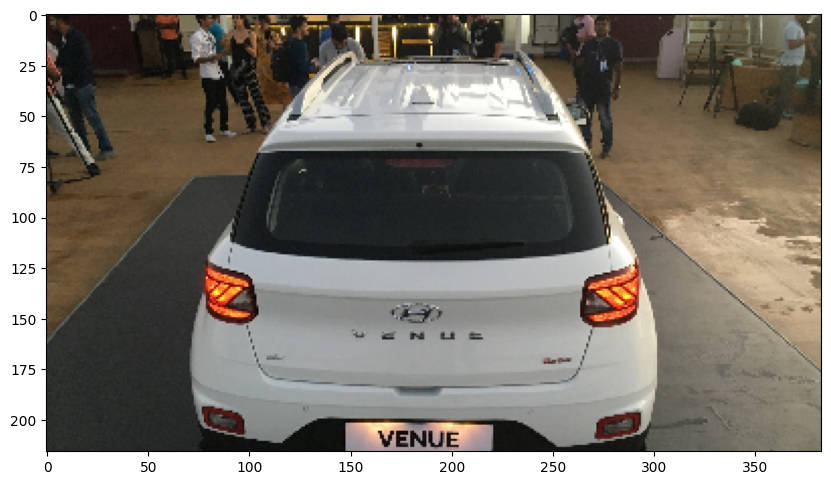

In [7]:
image_input = cv2.imread(paths[N])
image_input = cv2.resize(image_input,dsize=None,fx=0.2,fy=0.2)

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0,10.0)
plt.imshow(cv2.cvtColor(image_input, cv2.COLOR_BGR2RGB))
plt.show()

In [8]:
blob = cv2.dnn.blobFromImage(image_input, 1/255.0, (416,416), swapRB=True, crop=False)
blob_to_show = blob[0,:,:,:].transpose(1,2,0)
network.setInput(blob)
output_from_network = network.forward(layers_names_output)
np.random.seed(42)
colours = np.random.randint(0, 255, size=(len(labels), 3), dtype='uint8')

In [9]:
bounding_boxes = []
confidences = []
class_numbers = []
h,w = image_input.shape[:2]

for result in output_from_network:
    for detection in result:
        scores = detection[5:]
        class_current = np.argmax(scores)
        confidence_current = scores[class_current]
        if confidence_current > probability_minimum:
            box_current = detection[0:4] * np.array([w, h, w, h])
            x_center, y_center, box_width, box_height = box_current.astype('int')
            x_min = int(x_center-(box_width/2))
            y_min = int(y_center-(box_height/2))
            bounding_boxes.append([x_min, y_min, int(box_width), int(box_height)])
            confidences.append(float(confidence_current))
            class_numbers.append(class_current)   

In [10]:
results = cv2.dnn.NMSBoxes(bounding_boxes, confidences, probability_minimum, threshold)

# Tạo thư mục để lưu biển số xe
output_dir = './detected_license_plates'
os.makedirs(output_dir, exist_ok=True)

print(f"Tìm thấy {len(results)} biển số xe\n")

detected_plates = []

if len(results) > 0:
    for idx, i in enumerate(results.flatten(), 1):
        x_min, y_min = bounding_boxes[i][0], bounding_boxes[i][1]
        box_width, box_height = bounding_boxes[i][2], bounding_boxes[i][3]
        x_max = x_min + box_width
        y_max = y_min + box_height
        confidence = confidences[i]
        
        # Trích xuất vùng biển số
        plate_region = image_input[y_min:y_max, x_min:x_max]
        
        # Lưu ảnh biển số
        plate_filename = os.path.join(output_dir, f'license_plate_{idx}_conf_{confidence:.4f}.jpg')
        cv2.imwrite(plate_filename, plate_region)
        
        # Lưu thông tin biển số
        plate_info = {
            'id': idx,
            'x_min': x_min,
            'y_min': y_min,
            'x_max': x_max,
            'y_max': y_max,
            'width': box_width,
            'height': box_height,
            'confidence': confidence,
            'filename': plate_filename
        }
        detected_plates.append(plate_info)
        
        # In ra tọa độ các điểm
        print(f"Biển số xe {idx}:")
        print(f"  Tọa độ góc trên trái (x_min, y_min): ({x_min}, {y_min})")
        print(f"  Tọa độ góc dưới phải (x_max, y_max): ({x_max}, {y_max})")
        print(f"  Chiều rộng: {box_width}, Chiều cao: {box_height}")
        print(f"  Độ tin cậy: {confidence:.4f}")
        print(f"  Đã lưu: {plate_filename}\n")
        
        colour_box_current = [int(j) for j in colours[class_numbers[i]]]
        cv2.rectangle(image_input, (x_min, y_min), (x_max, y_max),
                      colour_box_current, 5)
        text_box_current = '{}: {:.4f}'.format(labels[int(class_numbers[i])], confidence)
        cv2.putText(image_input, text_box_current, (x_min, y_min - 7), cv2.FONT_HERSHEY_SIMPLEX,
                    1.5, colour_box_current, 5)
else:
    print("Không tìm thấy biển số xe nào")

Tìm thấy 0 biển số xe

Không tìm thấy biển số xe nào


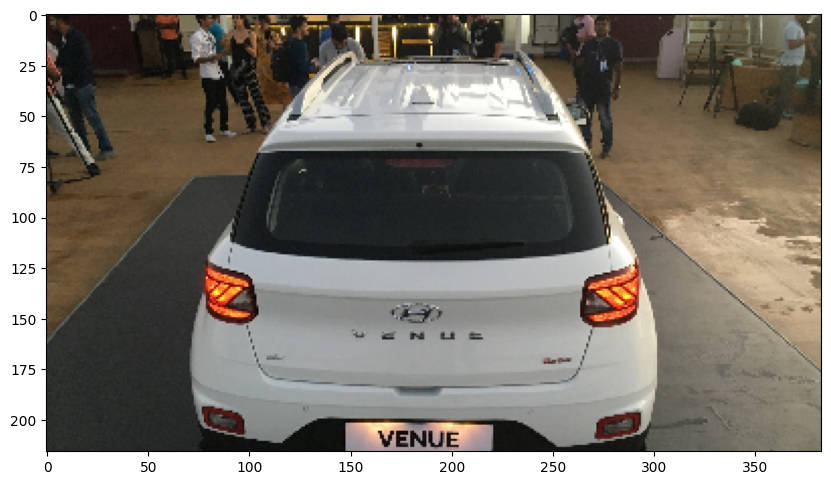

In [11]:
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0,10.0)
plt.imshow(cv2.cvtColor(image_input, cv2.COLOR_BGR2RGB))
plt.show()

In [12]:
# Lưu thông tin biển số vào file CSV
if detected_plates:
    import csv
    
    csv_file = os.path.join(output_dir, 'detected_plates_info.csv')
    with open(csv_file, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['id', 'x_min', 'y_min', 'x_max', 'y_max', 'width', 'height', 'confidence', 'filename'])
        writer.writeheader()
        writer.writerows(detected_plates)
    
    print(f"Đã lưu thông tin {len(detected_plates)} biển số xe vào: {csv_file}")
    print(f"Thư mục lưu: {os.path.abspath(output_dir)}")

In [13]:
%%capture
!pip install easyocr

In [14]:
# Khởi tạo EasyOCR reader
import easyocr

# Khởi tạo OCR cho tiếng Việt và English
reader = easyocr.Reader(['vi', 'en'], gpu=False)  # gpu=True nếu có GPU
print("✓ EasyOCR initialized successfully!")
print(f"Supported languages: Vietnamese, English")

Using CPU. Note: This module is much faster with a GPU.


✓ EasyOCR initialized successfully!
Supported languages: Vietnamese, English


In [15]:
# Hàm OCR để nhận dạng ký tự trên biển số
def recognize_license_plate_text(plate_image, reader, confidence_threshold=0.3):
    """
    Nhận dạng ký tự trên ảnh biển số
    """
    try:
        # Thực hiện OCR
        results = reader.readtext(plate_image)
        
        # Lọc kết quả có độ tin cậy cao
        recognized_text = []
        ocr_confidence = []
        
        for (bbox, text, conf) in results:
            if conf > confidence_threshold:
                recognized_text.append(text)
                ocr_confidence.append(conf)
        
        # Ghép text lại
        plate_text = ' '.join(recognized_text) if recognized_text else "Không nhận diện"
        avg_confidence = sum(ocr_confidence) / len(ocr_confidence) if ocr_confidence else 0
        
        return plate_text, avg_confidence
    except Exception as e:
        return f"Lỗi OCR: {str(e)}", 0.0

# Test OCR trên 1 ảnh
print("Testing OCR function...")
if detected_plates:
    test_plate_path = detected_plates[0]['filename']
    test_plate_img = cv2.imread(test_plate_path)
    text, conf = recognize_license_plate_text(test_plate_img, reader)
    print(f"✓ OCR Test: Text='{text}', Confidence={conf:.4f}")

Testing OCR function...


In [16]:
# Batch Processing Function - Xử lý toàn bộ dataset
def batch_process_images(image_paths, network, layers_names_output, reader, 
                        prob_min=0.4, conf_threshold=0.3,
                        max_images=None, display_progress=True):
    """
    Xử lý batch ảnh: detection + OCR
    """
    results_batch = []
    
    if max_images:
        image_paths = image_paths[:max_images]
    
    total_images = len(image_paths)
    detected_count = 0
    
    for idx, img_path in enumerate(image_paths, 1):
        if display_progress and idx % 10 == 0:
            print(f"Processing: {idx}/{total_images} images...")
        
        try:
            # Đọc ảnh
            img = cv2.imread(img_path)
            if img is None:
                continue
            
            original_h, original_w = img.shape[:2]
            img_resized = cv2.resize(img, dsize=None, fx=0.2, fy=0.2)
            h, w = img_resized.shape[:2]
            
            # Detection
            blob = cv2.dnn.blobFromImage(img_resized, 1/255.0, (416,416), swapRB=True, crop=False)
            network.setInput(blob)
            output = network.forward(layers_names_output)
            
            boxes = []
            confidences_list = []
            
            for result in output:
                for detection in result:
                    scores = detection[5:]
                    class_id = np.argmax(scores)
                    confidence = scores[class_id]
                    
                    if confidence > prob_min:
                        box = detection[0:4] * np.array([w, h, w, h])
                        x_center, y_center, box_w, box_h = box.astype('int')
                        x_min = int(x_center - box_w/2)
                        y_min = int(y_center - box_h/2)
                        boxes.append([x_min, y_min, int(box_w), int(box_h)])
                        confidences_list.append(float(confidence))
            
            # NMS
            if boxes:
                indices = cv2.dnn.NMSBoxes(boxes, confidences_list, prob_min, conf_threshold)
                
                for i in indices.flatten():
                    x_min, y_min = boxes[i][0], boxes[i][1]
                    box_w, box_h = boxes[i][2], boxes[i][3]
                    x_max = x_min + box_w
                    y_max = y_min + box_h
                    
                    # Scale back to original size
                    scale = 5  # Vì resize 0.2 = 1/5
                    x_min_orig = x_min * scale
                    y_min_orig = y_min * scale
                    x_max_orig = x_max * scale
                    y_max_orig = y_max * scale
                    
                    # Crop plate
                    plate_region = img[y_min_orig:y_max_orig, x_min_orig:x_max_orig]
                    
                    # OCR
                    plate_text, ocr_conf = recognize_license_plate_text(plate_region, reader)
                    
                    result_item = {
                        'image_path': img_path,
                        'image_name': os.path.basename(img_path),
                        'detection_conf': confidences_list[i],
                        'plate_text': plate_text,
                        'ocr_confidence': ocr_conf,
                        'x_min': x_min_orig,
                        'y_min': y_min_orig,
                        'x_max': x_max_orig,
                        'y_max': y_max_orig,
                        'width': x_max_orig - x_min_orig,
                        'height': y_max_orig - y_min_orig
                    }
                    results_batch.append(result_item)
                    detected_count += 1
        
        except Exception as e:
            print(f"Error processing {img_path}: {str(e)}")
            continue
    
    print(f"\n✓ Batch processing complete!")
    print(f"  Total images processed: {total_images}")
    print(f"  License plates detected: {detected_count}")
    
    return results_batch

print("✓ Batch processing function created successfully!")

✓ Batch processing function created successfully!


In [ ]:
# Chạy Batch Processing
import time

# Xử lý TOÀN BỘ dataset
print("Starting batch processing on dataset...")
print("=" * 60)

start_time = time.time()

# Lấy tổng số lượng ảnh trong dataset
total_images = len(paths) 

batch_results = batch_process_images(
    paths,
    network,
    layers_names_output,
    reader,
    prob_min=probability_minimum,
    conf_threshold=threshold,
    max_images=total_images,  # Thay đổi từ 50 thành total_images để chạy hết
    display_progress=True
)

end_time = time.time()
processing_time = end_time - start_time

print("=" * 60)
print(f"Total images processed: {total_images}")
print(f"Processing time: {processing_time:.2f} seconds")
# Tự động tính thời gian trung bình dựa trên tổng số ảnh thực tế đã xử lý
print(f"Average time per image: {processing_time/total_images:.2f}s")
print(f"\nTotal results: {len(batch_results)} license plates detected")

Starting batch processing on dataset...


c:\Users\huy.ngoc\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Processing: 10/931 images...
Processing: 20/931 images...
Processing: 30/931 images...
Processing: 40/931 images...
Processing: 50/931 images...
Processing: 60/931 images...
Processing: 70/931 images...
Processing: 80/931 images...
Processing: 90/931 images...
Processing: 100/931 images...
Processing: 110/931 images...
Processing: 120/931 images...
Processing: 130/931 images...
Processing: 140/931 images...
Processing: 150/931 images...
Processing: 160/931 images...
Processing: 170/931 images...
Processing: 180/931 images...
Processing: 190/931 images...
Processing: 200/931 images...
Processing: 210/931 images...
Processing: 220/931 images...
Processing: 230/931 images...
Processing: 240/931 images...
Processing: 250/931 images...
Processing: 260/931 images...
Processing: 270/931 images...
Processing: 280/931 images...
Processing: 290/931 images...
Processing: 300/931 images...
Processing: 310/931 images...
Processing: 320/931 images...
Processing: 330/931 images...
Processing: 340/931

In [ ]:
# Tạo Report & Export Results
import json
from datetime import datetime

# Tạo thư mục batch results
batch_output_dir = './batch_results'
os.makedirs(batch_output_dir, exist_ok=True)

# 1. Export to CSV
csv_batch_file = os.path.join(batch_output_dir, 'batch_detection_results.csv')
if batch_results:
    df_batch = pd.DataFrame(batch_results)
    df_batch.to_csv(csv_batch_file, index=False, encoding='utf-8')
    print(f"Exported to CSV: {csv_batch_file}")

# 2. Export to JSON
json_batch_file = os.path.join(batch_output_dir, 'batch_detection_results.json')
with open(json_batch_file, 'w', encoding='utf-8') as f:
    json.dump(batch_results, f, ensure_ascii=False, indent=2)
    print(f"Exported to JSON: {json_batch_file}")

# 3. Tạo Statistics Report
stats = {
    'timestamp': datetime.now().isoformat(),
    'total_images_processed': total_images,
    'total_license_plates_detected': len(batch_results),
    'detection_rate': f"{len(batch_results) / min(50, len(paths)) * 100:.2f}%",
    'average_detection_confidence': np.mean([r['detection_conf'] for r in batch_results]) if batch_results else 0,
    'average_ocr_confidence': np.mean([r['ocr_confidence'] for r in batch_results]) if batch_results else 0,
}

# In Statistics
print("\n" + "=" * 60)
print("BATCH PROCESSING STATISTICS")
print("=" * 60)
for key, value in stats.items():
    print(f"{key}: {value}")

# 4. Hiển thị Top 10 Recognized Plates
print("\n" + "=" * 60)
print("TOP 10 RECOGNIZED LICENSE PLATES")
print("=" * 60)
if batch_results:
    sorted_results = sorted(batch_results, key=lambda x: x['ocr_confidence'], reverse=True)
    for idx, result in enumerate(sorted_results[:10], 1):
        print(f"{idx}. Text: {result['plate_text']:<20} | OCR Conf: {result['ocr_confidence']:.4f} | Detection Conf: {result['detection_conf']:.4f}")

# 5. Export Statistics
stats_file = os.path.join(batch_output_dir, 'statistics.json')
with open(stats_file, 'w', encoding='utf-8') as f:
    json.dump(stats, f, ensure_ascii=False, indent=2)
    print(f"\n✓ Statistics saved to: {stats_file}")

print(f"\n✓ All results saved to: {os.path.abspath(batch_output_dir)}")

Exported to CSV: ./batch_results\batch_detection_results.csv
Exported to JSON: ./batch_results\batch_detection_results.json

BATCH PROCESSING STATISTICS
timestamp: 2026-05-27T11:19:19.556065
total_images_processed: 931
total_license_plates_detected: 726
detection_rate: 1452.00%
average_detection_confidence: 0.9657783445904734
average_ocr_confidence: 0.672194423210893

TOP 10 RECOGNIZED LICENSE PLATES
1. Text: 3088                 | OCR Conf: 1.0000 | Detection Conf: 0.9998
2. Text: 8866                 | OCR Conf: 0.9999 | Detection Conf: 0.4094
3. Text: MH 43 BK 8262        | OCR Conf: 0.9999 | Detection Conf: 0.9976
4. Text: IND                  | OCR Conf: 0.9998 | Detection Conf: 0.9448
5. Text: MH12 GR 4628         | OCR Conf: 0.9998 | Detection Conf: 0.9997
6. Text: IND                  | OCR Conf: 0.9997 | Detection Conf: 0.9993
7. Text: IND                  | OCR Conf: 0.9997 | Detection Conf: 0.9998
8. Text: MH 43 BN 4657        | OCR Conf: 0.9996 | Detection Conf: 0.6295
9. T

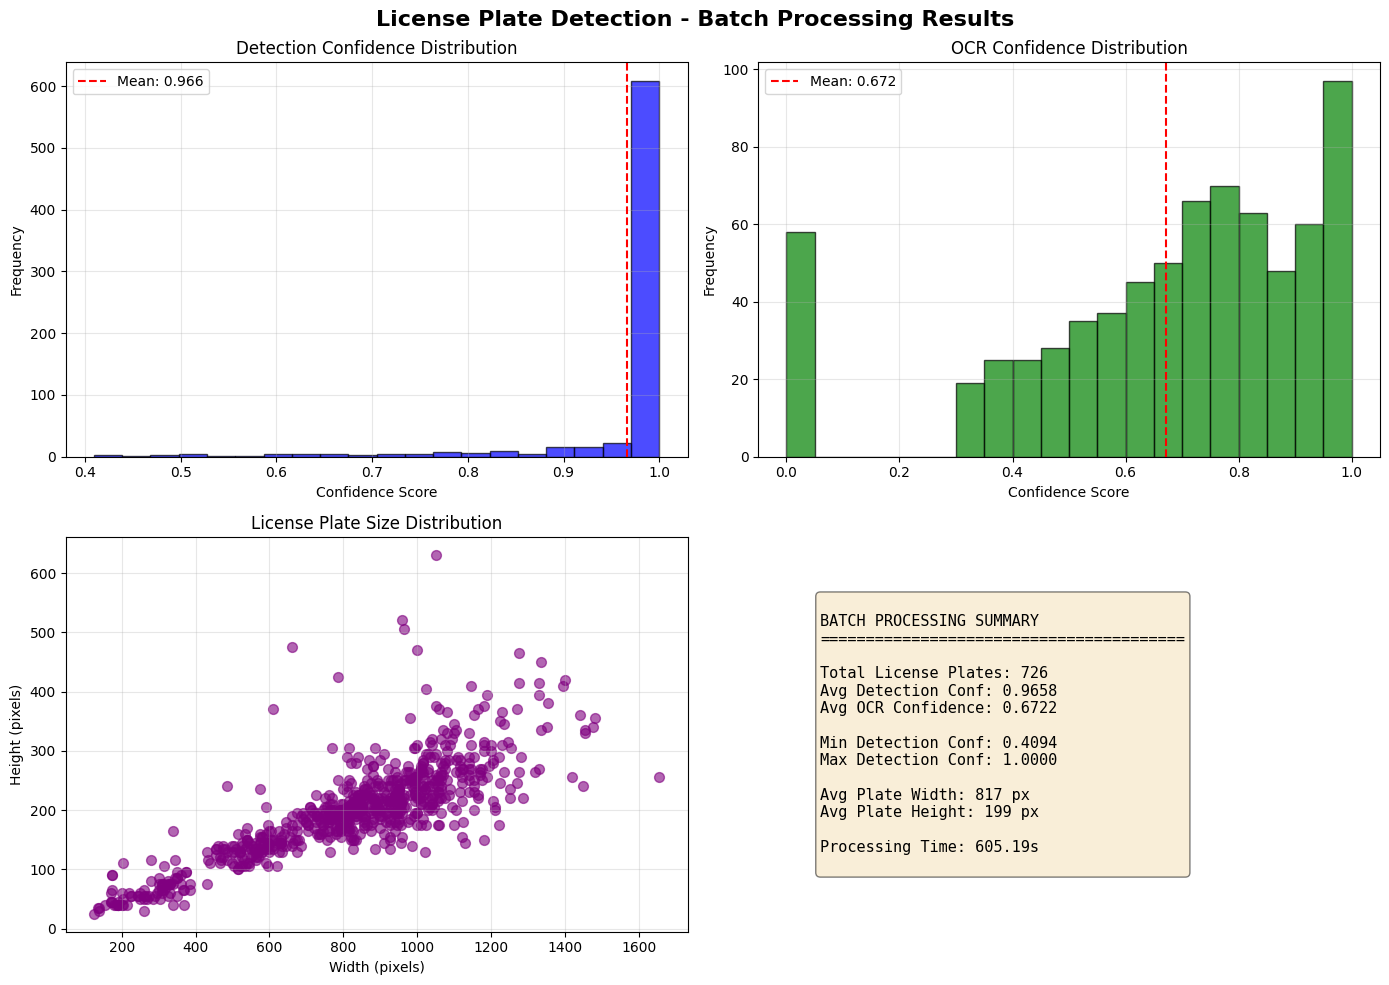

✓ Visualization saved to batch_results/


In [ ]:
# Visualization - Biểu đồ thống kê
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('License Plate Detection - Batch Processing Results', fontsize=16, fontweight='bold')

if batch_results:
    # 1. Confidence Distribution
    det_confidences = [r['detection_conf'] for r in batch_results]
    ocr_confidences = [r['ocr_confidence'] for r in batch_results]
    
    axes[0, 0].hist(det_confidences, bins=20, alpha=0.7, color='blue', edgecolor='black')
    axes[0, 0].set_title('Detection Confidence Distribution')
    axes[0, 0].set_xlabel('Confidence Score')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].axvline(np.mean(det_confidences), color='red', linestyle='--', label=f'Mean: {np.mean(det_confidences):.3f}')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # 2. OCR Confidence
    axes[0, 1].hist(ocr_confidences, bins=20, alpha=0.7, color='green', edgecolor='black')
    axes[0, 1].set_title('OCR Confidence Distribution')
    axes[0, 1].set_xlabel('Confidence Score')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].axvline(np.mean(ocr_confidences), color='red', linestyle='--', label=f'Mean: {np.mean(ocr_confidences):.3f}')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)
    
    # 3. Plate Size Distribution
    widths = [r['width'] for r in batch_results]
    heights = [r['height'] for r in batch_results]
    
    axes[1, 0].scatter(widths, heights, alpha=0.6, s=50, color='purple')
    axes[1, 0].set_title('License Plate Size Distribution')
    axes[1, 0].set_xlabel('Width (pixels)')
    axes[1, 0].set_ylabel('Height (pixels)')
    axes[1, 0].grid(alpha=0.3)
    
    # 4. Summary Statistics
    axes[1, 1].axis('off')
    summary_text = f"""
BATCH PROCESSING SUMMARY
{'='*40}

Total License Plates: {len(batch_results)}
Avg Detection Conf: {np.mean(det_confidences):.4f}
Avg OCR Confidence: {np.mean(ocr_confidences):.4f}

Min Detection Conf: {np.min(det_confidences):.4f}
Max Detection Conf: {np.max(det_confidences):.4f}

Avg Plate Width: {np.mean(widths):.0f} px
Avg Plate Height: {np.mean(heights):.0f} px

Processing Time: {processing_time:.2f}s
    """
    axes[1, 1].text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
                   verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(os.path.join(batch_output_dir, 'batch_statistics_visualization.png'), dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualization saved to batch_results/")